Data preprocessing
step 1 - data understanding / business understanding
titanic dataset--used to study data science in most courses
steps:
1- read data
2- check dtypes [data may have dependency:??]
3- handle dtype 
4- check nulls
5- handling nulls
6- check outliers
7- handling outliers
8- check duplicated
9- handling duplicated
10- data visualization
    Machine learning starts here:
11- data splitting [??]
12- Normalization [task coming about this, scaling of data, smoothing]
13- encoding 

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('Titanic.csv')

In [3]:
DROP_COLS = ["PassengerId",
             "Name",
             "Ticket"]
def drop_cols(df: pd.DataFrame, cols: list[str])->pd.DataFrame:
    return df.drop(columns=cols)


In [4]:
drop_cols(df, DROP_COLS)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


In [5]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


drop columns that we don't need

In [6]:
df.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True) #axis = 1 means i'm dropping columns, axis = 0 i'm dropping rows, inplace=true means ...

In [7]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


checking dtype & handling dtype
limited ..descrete..categorical
big numbers ..continuous

In [8]:
dtype = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype ":dtype, "N_unique ": n_uniq}).T


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
N_unique,2,3,2,88,7,7,248,147,3


In [9]:
def chk_types(data):
    dtypes= df.dtypes
    n_uniq = df.nunique()

    return pd.DataFrame({"Dtype":dtypes, "Num_unique":n_uniq}).T


In [10]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [11]:
chk_types_table(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Unique,2,3,2,88,7,7,248,147,3


In [12]:
cols = ["Survived","Pclass","Sex","SibSp","Parch","Embarked"]
df[cols] = df[cols].astype("category")
#pd.DataFrame(df.dtypes).T
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,str,category
Num_unique,2,3,2,88,7,7,248,147,3


In [13]:
def get_data_summary(df):
    return pd.DataFrame({"Dtype ":df.dtype, "N_unique ": df.n_uniq}).T

handle null values
if most values existed and null is around 20% can fill the missing values using the historical data
if numerical col (and has outliers, noise) then use median instead of mean to fill the missing values
if col is string use mode to fill the missing values

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    category
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    category
 5   Parch     891 non-null    category
 6   Fare      891 non-null    float64 
 7   Cabin     204 non-null    str     
 8   Embarked  889 non-null    category
dtypes: category(6), float64(2), str(1)
memory usage: 26.4 KB


In [15]:
df.shape[0]  #number of rows

891

In [16]:
null = df.isnull().sum()
ratio = (null / df.shape[0])*100
pd.DataFrame({"null ":null, "ratio ": ratio}).T


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [17]:
median_1 = df['Age'].median()
df['Age'] =df['Age'].fillna(median_1, inplace=True)

C:\Users\newle\AppData\Local\Temp\ipykernel_15568\2454419046.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] =df['Age'].fillna(median_1, inplace=True)


In [18]:
df.dropna(subset=['Embarked'], inplace=True) #droped rows with nulls in the column embarked

In [19]:
null = df.isnull().sum()
ratio = (null / df.shape[0])*100
pd.DataFrame({"null ":null, "ratio %": ratio}).T


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,687.00000,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.27784,0.0


In [20]:
#df = df.drop("Cabin", axis=1)

check outliers

In [21]:
#!pip install matplotlib
#!pip install seaborn
#!pip install plotly

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

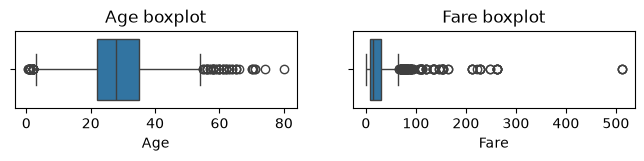

In [23]:

num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} boxplot")


In [24]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5* IQR
    upper_fence = Q3 +   1.5* IQR
    # print(lower_fence)
    lower_outliers = df[   df[col] < lower_fence    ][col].values 
    upper_outliers = df[ df[col] > upper_fence][col].values 

    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)



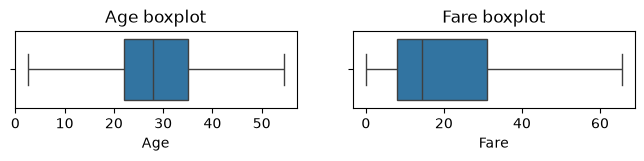

In [25]:
import matplotlib.pyplot as plt 
import seaborn as sns
num_cols  =  df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} boxplot")



In [26]:
df.duplicated().sum()

np.int64(116)

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
def removeduplicate(df, subset_cols=None, keep_stratgy = "first"):

    return (df.drop_duplicates(subset=subset_cols, keep=keep_stratgy).reset_index(drop = True))

In [30]:
num_cols

Index(['Age', 'Fare'], dtype='str')

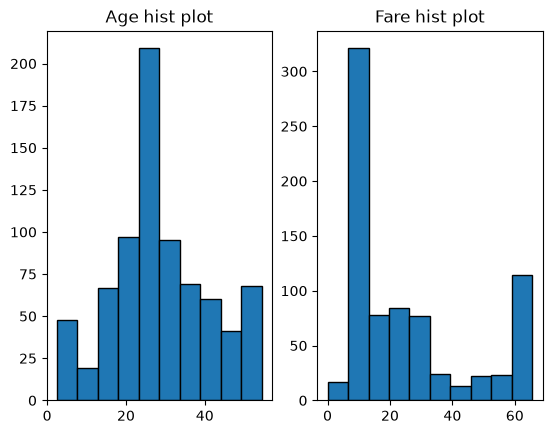

In [31]:
# fixed
plt.Figure(figsize=(9*len(num_cols),4))
for i, col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist plot")


In [32]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

In [33]:
df['Survived'].value_counts()

Survived
0    453
1    320
Name: count, dtype: int64

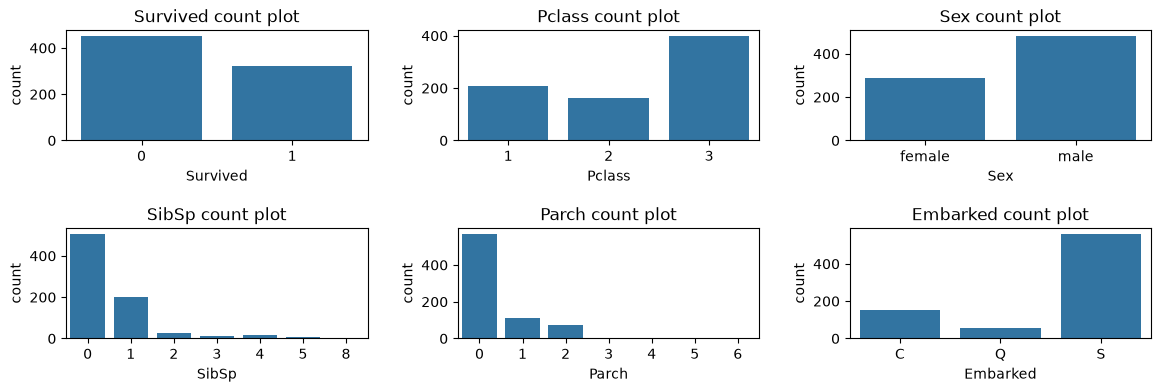

In [34]:
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2,3, i+1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} count plot")

plt.subplots_adjust(hspace =0.8, wspace=0.3)

In [35]:
unique = df['Survived'].value_counts()
#print(unique)
count = unique.values
categories = unique.index

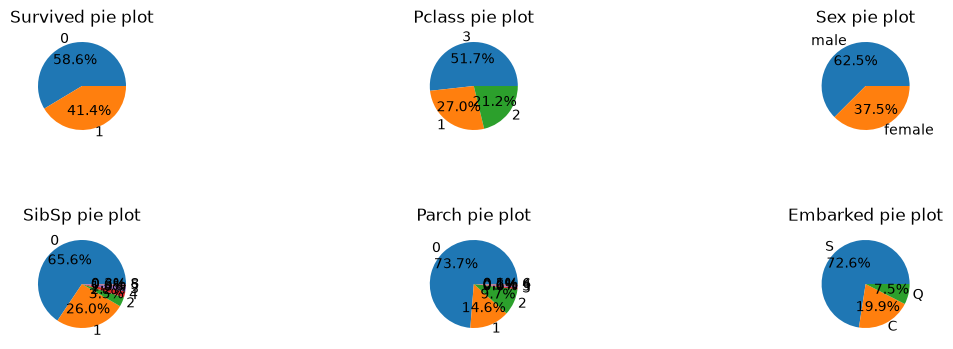

In [36]:
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2,3, i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels = categories, autopct='%1.1f%%')
    plt.title(f"{col} pie plot")

plt.subplots_adjust(hspace =0.8, wspace=0.3)

In [37]:
#pip install ipython
#!pip install nbformat

In [38]:
import plotly.express as px
fig = px.pie(df, names = "Survived",
       title="<b> survived pie plot</b>",
       color_discrete_sequence=px.colors.qualitative.Pastel,
       hole=0.4
       
       )
fig.update_layout(annotations = [dict(text= "Survived", font_size=20, x=0.5, y =0.5, showarrow = False)])

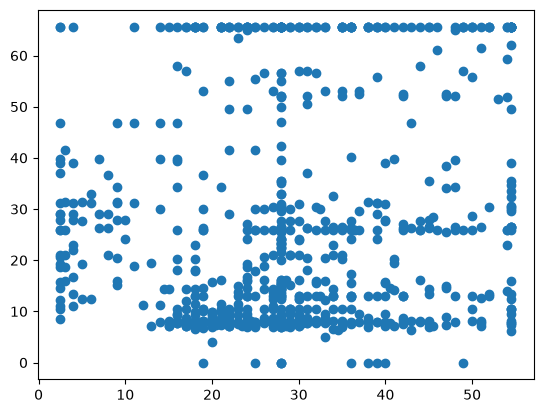

In [44]:
plt.Figure(figsize=(2,2))
plt.scatter(df['Age'], df['Fare'])

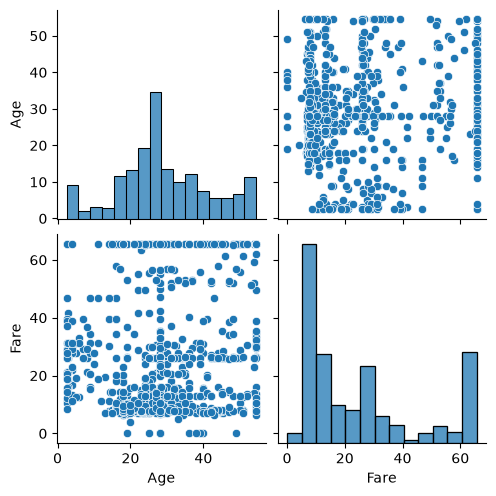

In [40]:
sns.pairplot(df)

<Axes: >

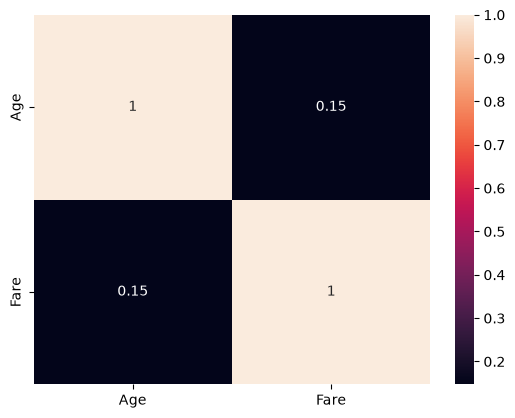

In [41]:
corr = df[num_cols].corr()
plt.Figure(figsize=(2,2))
sns.heatmap(corr, annot=True)

In [42]:
num_cols = df.select_dtypes("number").columns
for col in num_cols:
    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(0.75)
    #print(Q1,Q3)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 - 1.5*IQR
    print(lower_fence)
    lower_outliers = df[df[col] < lower_fence][col].values
    print(lower_outliers)
    upper_outliers = df[df[col] > upper_fence][col].values
    #print(upper_outliers)

-1.5
[]
-29.374999999999996
[]


In [43]:
df.describe()

,Age,Fare
count,773.000000,773.000000
mean,29.114489,25.342199
std,12.615252,20.651022
min,2.500000,0.000000
25%,21.000000,8.050000
50%,28.000000,15.850000
75%,36.000000,33.000000
max,54.500000,65.656300
